In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os

# List everything in the top level of your Drive
for item in sorted(os.listdir('/content/drive/MyDrive/Physics 3rd Yr/PHAS0056: Machine Learning/Final Proj/')):
    print(item)

main_dir = '/content/drive/MyDrive/Physics 3rd Yr/PHAS0056: Machine Learning/Final Proj/' #main directory on Google Drive

Mounted at /content/drive
Notebooks
Reference Papers1. .gdoc
Results
data_files
datasets
lhcJets.ipynb


In [2]:
import h5py
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from sklearn.utils import shuffle
print(os.getcwd())

/content


In [3]:
import tensorflow as tf
print(tf)
print(getattr(tf, "__file__", "no file location"))


<module 'tensorflow' from '/usr/local/lib/python3.12/dist-packages/tensorflow/__init__.py'>
/usr/local/lib/python3.12/dist-packages/tensorflow/__init__.py


In [4]:
import matplotlib.pyplot as plt
import numpy as np
import math

# TensorFlow and tf.keras
import tensorflow as tf
from tensorflow import keras

import matplotlib.style
import matplotlib as mpl
from scipy import linalg


#Set default figure size
#mpl.rcParams['figure.figsize'] = [12.0, 8.0] #Inches... of course it is inches
mpl.rcParams["legend.frameon"] = False
mpl.rcParams['figure.dpi']=200 # dots per inch

#Useful for debugging problems
print(tf.__version__)
print(np.__version__)

2.19.0
2.0.2


In [5]:
def lognorm_transform(img, vmin=0.01, vmax=1e3):
    '''
    Log-normalises jet images to [0, 1] range.
    Clips values below vmin to vmin before taking log,
    avoiding -inf and the need for a separate masking step.
    '''
    log_min = np.log(vmin)
    log_max = np.log(vmax)

    img_clipped = np.clip(img, vmin, vmax).astype(np.float32)
    img_log     = np.log(img_clipped)

    return (img_log - log_min) / (log_max - log_min)

In [6]:
def load_single_h5_img(file_path, channels='combined'):
    '''
    Loads individual jet images from one h5 file.
    Applies lognorm_transform immediately so the returned
    array is already float32 in [0,1] — no second pass needed.

    Returns
    -------
    images     : float32 array, shape (N, 100, 100) or (N, 100, 100, 3)
    int_labels : int array,     shape (N,)   — 0=Gluon 1=Quark 2=W 3=Z 4=Top
    '''
    try:
        df = h5py.File(file_path, 'r')
    except Exception as e:
        print("Error opening file:", e)
        raise

    # Integer class labels from one-hot columns
    feat_names = [l.decode('utf-8') for l in df['jetFeatureNames'][:]]
    pJet       = pd.DataFrame(np.array(df['jets']), columns=feat_names)
    label_cols = ['j_g', 'j_q', 'j_w', 'j_z', 'j_t']
    int_labels = np.argmax(pJet[label_cols].to_numpy(), axis=1)

    # Load images and transform immediately — before appending to the list
    if channels == 'combined':
        raw    = np.array(df['jetImage'][:])
        images = lognorm_transform(raw)                        # (N, 100, 100)

    elif channels == 'all':
        ch0 = lognorm_transform(np.array(df['jetImage'][:]))
        ch1 = lognorm_transform(np.array(df['jetImageECAL'][:]))
        ch2 = lognorm_transform(np.array(df['jetImageHCAL'][:]))
        images = np.stack([ch0, ch1, ch2], axis=-1)           # (N, 100, 100, 3)

    else:
        raise ValueError(f"channels must be 'combined' or 'all', got '{channels}'")

    df.close()
    return images, int_labels


In [7]:
def load_h5_features(main_dir, max_files=None):
    '''
    Loads jet feature variables from h5 files for Phase 3 analysis.
    Returns images, integer labels, and the full jet features dataframe.
    Does not save any .npy files.
    '''
    all_images   = []
    all_labels   = []
    all_features = []

    h5_files = sorted([f for f in os.listdir(main_dir) if f.endswith('.h5')])
    file_count = 0

    for fname in h5_files:
        if max_files is not None and file_count >= max_files:
            break

        path = os.path.join(main_dir, fname)
        try:
            df = h5py.File(path, 'r')

            feat_names = [l.decode('utf-8') for l in df['jetFeatureNames'][:]]
            pJet       = pd.DataFrame(np.array(df['jets']), columns=feat_names)

            label_cols = ['j_g', 'j_q', 'j_w', 'j_z', 'j_t']
            int_labels = np.argmax(pJet[label_cols].to_numpy(), axis=1)

            images = lognorm_transform(np.array(df['jetImage'][:]))

            all_images.append(images)
            all_labels.append(int_labels)
            all_features.append(pJet)

            df.close()
            file_count += 1
            print(f"Loaded {fname} ({images.shape[0]:,} jets)")

        except Exception as e:
            print(f"Skipped {fname}: {e}")
            continue

    all_images   = np.concatenate(all_images,   axis=0)
    all_labels   = np.concatenate(all_labels,   axis=0)
    all_features = pd.concat(all_features, ignore_index=True)

    print(f"\nTotal: {all_images.shape[0]:,} jets, {all_features.shape[1]} features")
    return all_images, all_labels, all_features

In [8]:
# Run validation h5 files — same max_files as before
val_images_p3, val_labels_p3, val_features = load_h5_features( main_dir= main_dir+
    '/data_files/val', max_files=3
)

val_images_p3 = val_images_p3[..., np.newaxis]

Loaded jetImage_7_100p_0_10000.h5 (10,000 jets)
Loaded jetImage_7_100p_10000_20000.h5 (10,000 jets)
Loaded jetImage_7_100p_30000_40000.h5 (10,000 jets)

Total: 30,000 jets, 59 features


**Note:**

*Due to the structure of the publicly available HLS4ML dataset, a separate held-out test set was not available. The validation set (files 7–9), which was used only for early stopping during training and not for weight updates, is used for all reported evaluation metrics.*

In [15]:
val_images_p3, val_labels_p3, val_features = shuffle(val_images_p3, val_labels_p3, val_features, random_state = 42)


val_images_p3.shape, val_labels_p3.shape, val_features.shape


((30000, 100, 100, 1), (30000,), (30000, 59))

In [16]:
# Check the feature columns available
print(val_features.columns.tolist())

# Check the three variables you'll use
print(val_features[['j_pt', 'j_mass', 'j_multiplicity']].describe())

['j_ptfrac', 'j_pt', 'j_eta', 'j_mass', 'j_tau1_b1', 'j_tau2_b1', 'j_tau3_b1', 'j_tau1_b2', 'j_tau2_b2', 'j_tau3_b2', 'j_tau32_b1', 'j_tau32_b2', 'j_zlogz', 'j_c1_b0', 'j_c1_b1', 'j_c1_b2', 'j_c2_b1', 'j_c2_b2', 'j_d2_b1', 'j_d2_b2', 'j_d2_a1_b1', 'j_d2_a1_b2', 'j_m2_b1', 'j_m2_b2', 'j_n2_b1', 'j_n2_b2', 'j_tau1_b1_mmdt', 'j_tau2_b1_mmdt', 'j_tau3_b1_mmdt', 'j_tau1_b2_mmdt', 'j_tau2_b2_mmdt', 'j_tau3_b2_mmdt', 'j_tau32_b1_mmdt', 'j_tau32_b2_mmdt', 'j_c1_b0_mmdt', 'j_c1_b1_mmdt', 'j_c1_b2_mmdt', 'j_c2_b1_mmdt', 'j_c2_b2_mmdt', 'j_d2_b1_mmdt', 'j_d2_b2_mmdt', 'j_d2_a1_b1_mmdt', 'j_d2_a1_b2_mmdt', 'j_m2_b1_mmdt', 'j_m2_b2_mmdt', 'j_n2_b1_mmdt', 'j_n2_b2_mmdt', 'j_mass_trim', 'j_mass_mmdt', 'j_mass_prun', 'j_mass_sdb2', 'j_mass_sdm1', 'j_multiplicity', 'j_g', 'j_q', 'j_w', 'j_z', 'j_t', 'j_undef']
               j_pt        j_mass  j_multiplicity
count  30000.000000  30000.000000    30000.000000
mean    1046.628771     93.945128       51.708833
std      125.433896     43.393448       21.59

In [17]:
##Loading trained model_v1 model ##

model_v1_dir = main_dir + '/Results/Model_v1'

model_v1 = tf.keras.models.load_model(model_v1_dir+ '/jet_cnn_v1.keras')
model_v1.summary()  # confirm it loaded correctly

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 100, 100, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 100, 100, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 50, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 50, 50, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 50, 50, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 25, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 25, 25, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_6 (LeakyReLU)       │ (None, 25, 25, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     4,718,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_7 (LeakyReLU)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,438,417 (55.08 MB)

 Trainable params: 4,812,805 (18.36 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 9,625,612 (36.72 MB)

In [18]:
CLASS_NAMES = ['Gluon', 'Quark', 'W', 'Z', 'Top']
COLOURS     = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00']

# Get predictions on the phase 3 validation set
logits_p3      = model_v1.predict(val_images_p3, batch_size=64)
pred_labels_p3 = np.argmax(logits_p3, axis=1)
correct_p3     = (pred_labels_p3 == val_labels_p3)  # boolean array — True if correct

469/469 ━━━━━━━━━━━━━━━━━━━━ 283s 601ms/step


In [19]:
def plot_efficiency_vs_feature(feature_vals, correct, true_labels,
                                feature_name, bins, xlabel,
                                save_path=None):
    '''
    Plots per-class classification efficiency as a function of a jet feature.

    feature_vals : 1D array of the feature values (e.g. j_pt)
    correct      : boolean array — True where prediction == true label
    true_labels  : integer class labels
    bins         : array of bin edges
    '''
    bin_centres = 0.5 * (bins[:-1] + bins[1:])

    fig, ax = plt.subplots(figsize=(8, 5))

    for i, (name, colour) in enumerate(zip(CLASS_NAMES, COLOURS)):
        # Select only jets of this true class
        class_mask = (true_labels == i)

        efficiencies = []
        errors       = []

        for j in range(len(bins) - 1):
            # Jets of this class in this bin
            bin_mask = (feature_vals >= bins[j]) & (feature_vals < bins[j+1])
            combined = class_mask & bin_mask

            n_total   = np.sum(combined)
            n_correct = np.sum(correct[combined])

            if n_total > 0:
                eff = n_correct / n_total
                err = np.sqrt(eff * (1 - eff) / n_total)  # binomial error
            else:
                eff = 0.0
                err = 0.0

            efficiencies.append(eff)
            errors.append(err)

        ax.errorbar(
            bin_centres, efficiencies, yerr=errors,
            color=colour, linewidth=2, marker='o',
            markersize=4, label=name, capsize=3
        )

    ax.set_xlabel(xlabel)
    ax.set_ylabel("Classification efficiency")
    ax.set_title(f"Per-class efficiency vs {feature_name}")
    ax.legend(loc='best')
    ax.set_ylim([0.0, 1.05])
    ax.axhline(0.2, color='k', linestyle='--', linewidth=1, label='Random')
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
    plt.show()

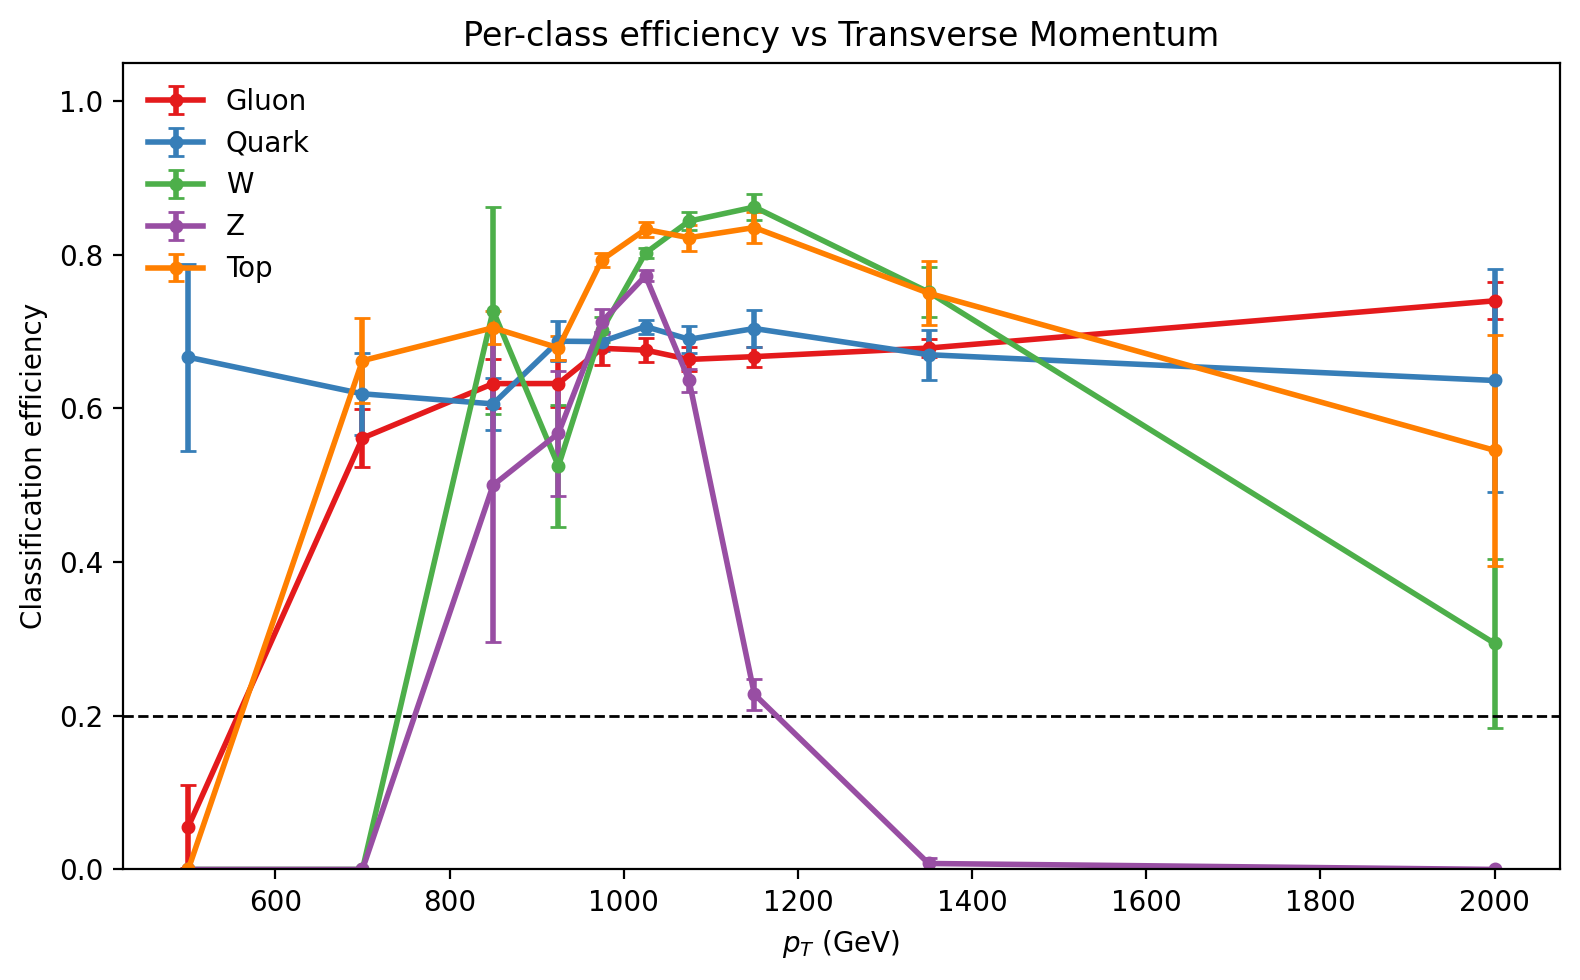

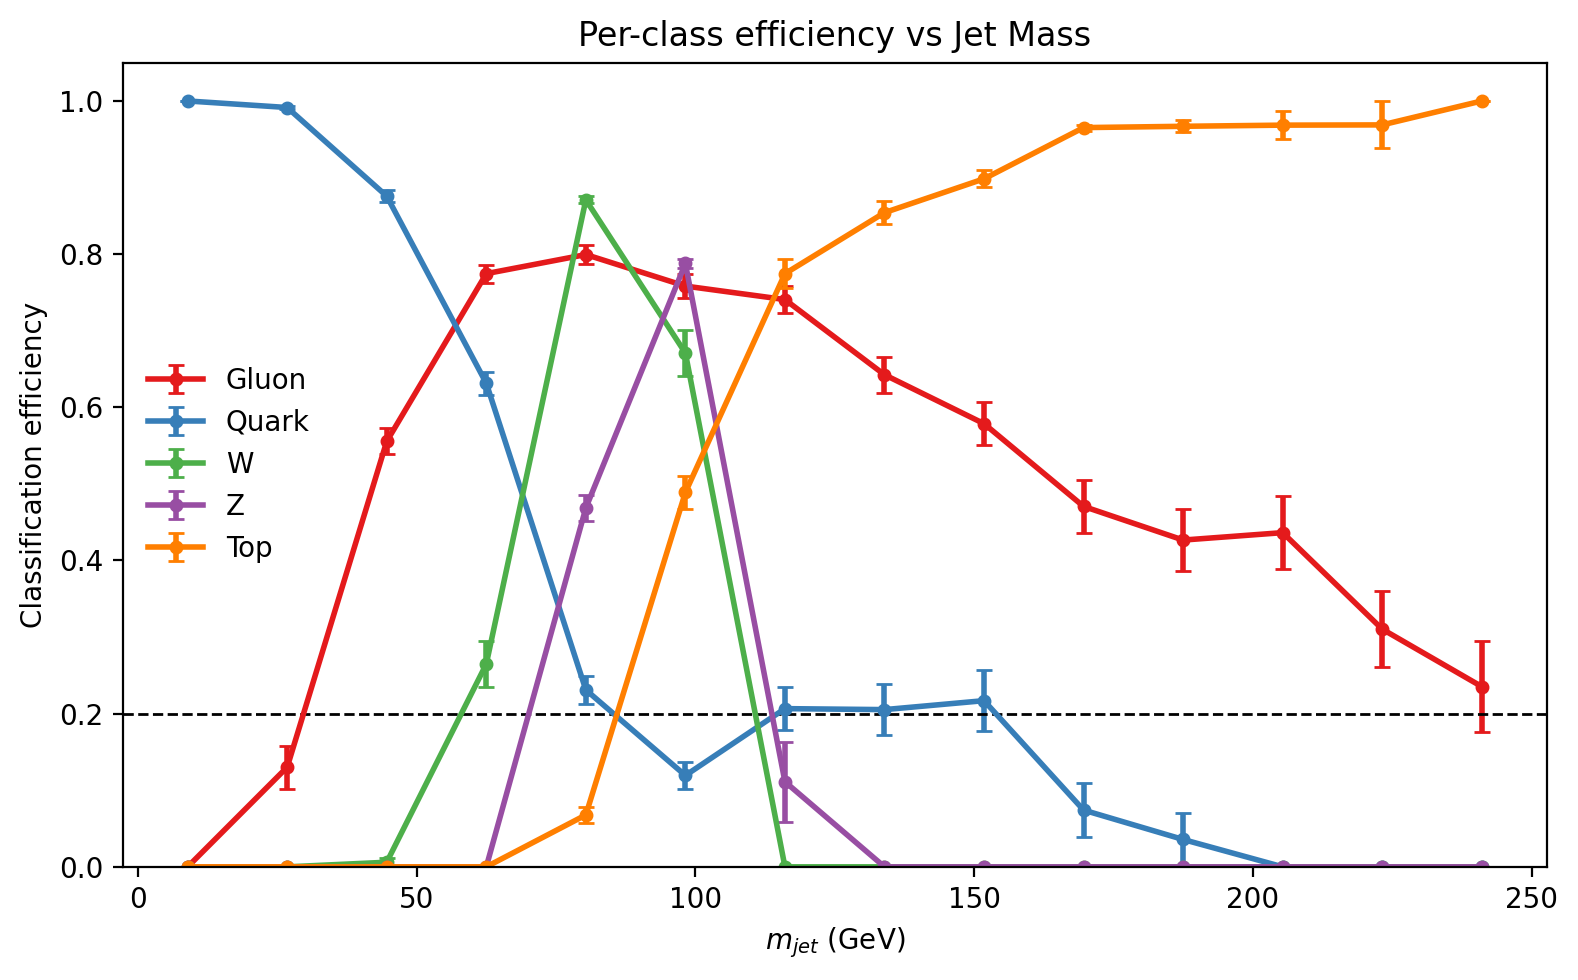

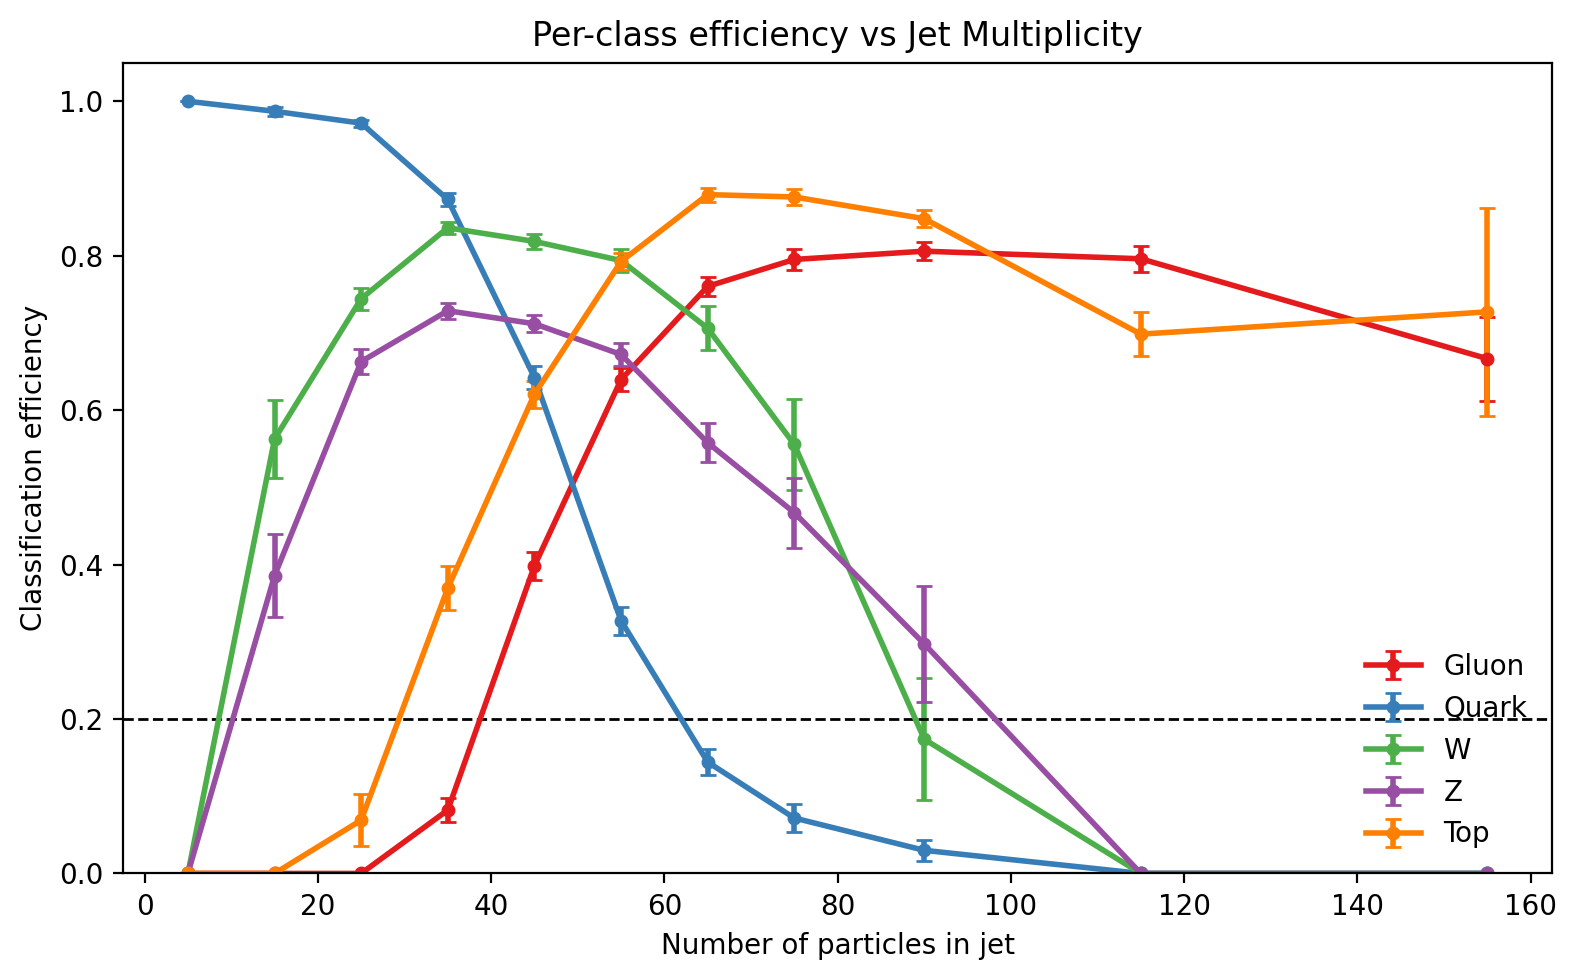

In [20]:
# ── Plot 1: efficiency vs j_pt ──
pt_bins = np.array([400, 600, 800, 900, 950, 1000, 1050, 1100, 1200, 1500, 2500])
plot_efficiency_vs_feature(
    feature_vals = val_features['j_pt'].to_numpy(),
    correct      = correct_p3,
    true_labels  = val_labels_p3,
    feature_name = 'Transverse Momentum',
    bins         = pt_bins,
    xlabel       = r'$p_T$ (GeV)',
    save_path    = model_v1_dir + '/Plots/efficiency_vs_pt'
)

# ── Plot 2: efficiency vs j_mass ──
mass_bins = np.linspace(0, 250, 15)
plot_efficiency_vs_feature(
    feature_vals = val_features['j_mass'].to_numpy(),
    correct      = correct_p3,
    true_labels  = val_labels_p3,
    feature_name = 'Jet Mass',
    bins         = mass_bins,
    xlabel       = r'$m_{jet}$ (GeV)',
    save_path    = model_v1_dir + '/Plots/efficiency_vs_mass.pdf'
)

# ── Plot 3: efficiency vs j_multiplicity ──
mult_bins = np.array([0, 10, 20, 30, 40, 50, 60, 70, 80, 100, 130, 180])
plot_efficiency_vs_feature(
    feature_vals = val_features['j_multiplicity'].to_numpy(),
    correct      = correct_p3,
    true_labels  = val_labels_p3,
    feature_name = 'Jet Multiplicity',
    bins         = mult_bins,
    xlabel       = 'Number of particles in jet',
    save_path    = model_v1_dir + '/Plots/efficiency_vs_multiplicity.pdf'
)

## Error Calculation: ##

Errors for the above graphs were calculated using the binomial error formula - standrd statisitcal uncertainity for an efficiency measurement.

For each bin, the efficiency is given by:

$$ ϵ = \frac{n_{correct}}{n_{total}} $$



Since either the jet is classified as correct (True) or inccorrect (False), this is described by a binomial process; therefore, standard error follows the formula for standard error for a binomial distribution with n samples:


$$ σ_{ϵ} = \sqrt{\frac{ϵ(1-ϵ)}{n_{total}}}$$

The error bars represent the binomial statistical uncertainty. Bins with large errors to be approached carefully due to low sample size.


## Results: ##

### 1. Efficiency vs Jet Mass: ###
  - Quark (blue) peaks near ~0–30 GeV with nearly 100% efficiency — quark jets are low mass, essentially massless compared to heavy particles, and the model has learned this perfectly
   - W (green) peaks sharply at ~75–85 GeV — this is exactly the W boson mass of 80.4 GeV. The CNN has learned the W boson mass peak from the jet images alone without being told what mass is
  - Z (purple) peaks at ~90–100 GeV — matching the Z boson mass of 91.2 GeV, shifted slightly higher than W as expected
   - Top (orange) rises continuously and reaches ~97–100% efficiency above 150 GeV — consistent with the top quark mass of 173 GeV producing very high-mass jets
  - Gluon (red) is broad and peaks around 60–100 GeV, reflecting the wide mass distribution of gluon-initiated showers

RESULT: The CNN has learned implicitly the W and Z boson masses purely from pixel-level calorimeter images without any explicit mass information.

Citations:
- [1] Workman et al. (Particle Data Group), Prog. Theor. Exp. Phys. 2022, 083C01 (2022) — cites the established W boson mass of 80.377 GeV and Z boson mass of 91.1876 GeV
- [2] Thaler & Van Tilburg (2011) — "Identifying boosted objects with N-subjettiness", JHEP 03 (2011) 015, arXiv:1011.2268 - jet mass combined with substructure variables is the standard tool for identifying boosted W, Z and top jets in HEP. EFficiency vs mass plot is the CNN equivalent of this traditional approach.
- [3] Kasieczka et al. (2017), "Deep-learning Top Taggers or The End of QCD?", JHEP 05 (2017) 006 (arXiv:1701.08784), extended this to top quark tagging using CNNs on calorimeter images, viewing the azimuthal angle vs rapidity plane with calorimeter entries as a sparsely filled image where filled pixels correspond to calorimeter cells with non-zero energy deposits and pixel intensities to the deposited energy. They confirmed that the CNN learns all the appropriate sub-jet patterns from the image alone, including the mass drop structure associated with the top quark decay chain - confirms that deep networks trained on calorimeter images can learn physical substructure features such as jet mass without explicit supervision.


### 2. Efficiency vs Multiplicity: ###

- Quark (blue) dominates at very low multiplicity (under 30 particles) with ~100% efficiency then collapses — quark jets are narrow and sparse, producing few particles
- W (green) and Z (purple) peak at 25–40 particles — both decay to two quarks, producing a moderate number of particles, and both drop sharply above 50 reflecting their 2-prong structure
- Top (orange) rises slowly, peaks broadly around 60–90 particles — top quarks decay to three quarks (t → W + b → qqb) producing a rich, high-multiplicity jet, and the model correctly identifies this
- Gluon (red) is broad across 40–120 particles — gluon jets are known to be wider and more diffuse than quark jets, producing many soft particles across a wide range


RESULT: Most clear interpretable result - separation of very low multiplicity of Quark and high multiplicity of Top particles

Citations:

- [1] Gallicchio & Schwartz (2012) — "Quark and Gluon Jet Substructure" - comphrensive study of quark vs gluon jets discrimination variables - directly supports our observation that quark jets cluster at low multiplicities, while gluon jets spread to higher values
- [2] Larkoski, Moult & Nachman (2020) — "Jet Substructure at the LHC: A Review", Phys. Rept. 841:1–63 -gluon jets produce more partcles than quark jets due to larger colour Casimir factor
- [3] de Oliveira et al. (2016) — "Jet-images: deep learning edition", JHEP 07 (2016) 069 - investigates deep learning architectures trained on jet images to identify highly boost W bosons - findings consistent with W efficiency peaking at moderate mulitiplicity as we found from our plot.

### 3. Efficiency vs pT ###

- Gluon, Quark, Top are relatively flat above 700 GeV — the model works consistently across most of the pT range, which is what a good classifier should do
- W (green) rises to a peak around 1100–1200 GeV then drops sharply — this is physically interesting and suggests the model struggles to identify boosted W jets at very high pT where the two decay products merge into a single jet
- Z (purple) shows the most dramatic behaviour — it collapses almost to zero above 1100 GeV. At high pT, Z jets become so boosted that their substructure looks almost identical to W jets, and the model essentially stops being able to tell them apart, assigning most of them to the W class instead. This is directly consistent with the W/Z confusion in the confusion matrix.

RESULT: at high boost the W/Z distinction breaks down, which is a known challenge even for state-of-the-art taggers and is worth connecting to the literature

Citations:
- [1] Thaler & Van Tilburg (2011) — "Identifying Boosted Objects with N-subjettiness", JHEP 03 (2011) - foundational paper for boosted object identifiation. Because of W and Z bosons similar substructure, in this study they were treated as a two-prong cateogory - when studying bossted W bosons with Top quarks. Justification for why the model confuses W and Z bosnons.
- [2] Larkoski, Moult & Nachman (2020) - W and Z bosons have nearly identical masses and produce nearly identical two-prong jet structures, making them the hardest pair to distinguish of all the classes in the HLS4ML dataset
